# Análisis Exploratorio del Dataset de Reseñas de productos y cuidado de la piel de Sephora

Este notebook explora el dataset crudo compuesto por el catálogo de productos de cosmética y las valoraciones de sus clientes. Identificaremos valores faltantes ocultos y propondremos un flujo de limpieza, integración de datos y análisis adaptado al contexto del proyecto..

## Configuración del Entorno y la Carga de Datos
Para garantizar la consistencia de este análisis, hemos configurado el entorno de trabajo para que sea dinámico. El código detecta automáticamente si se está ejecutando en la nube (**Google Colab**) o en un entorno local (**Visual Studio Code**), ajustando las rutas de los archivos.

**Primera validación de datos:** En esta etapa procedemos a cargar el catálogo principal (`product_info.csv`) y a unificar los múltiples archivos de comentarios de usuarios (`reviews_*.csv`) en un solo conjunto de datos. Al momento de cargar los archivos, aplicamos una limpieza inicial utilizando el parámetro `na_values`. Esto asegura que los strings vacíos o textos como "NULL" sean interpretados correctamente por Pandas como valores faltantes (`NaN`), preparándolos para nuestro análisis de nulos.

In [2]:
# Se importan las libterías necesarias para el análisis de datos y visualización
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Se ocultan advertencias para mantener el notebook limpio
warnings.filterwarnings('ignore') # Aveces, las advertencias pueden ser molestas

# Se configuran la visualizacion para que se vea más profesional
# Lo que hace tu profesor:
sns.set_context("talk") # Escala automáticamente el tamaño de los elementos para presentaciones
sns.set_theme(
    style="whitegrid",
    rc={
        "axes.titlesize": 18,   # Títulos bien grandes
        "axes.labelsize": 14,   # Etiquetas de ejes legibles
        "xtick.labelsize": 12,  # Números de los ejes
        "ytick.labelsize": 12,
    },
)
plt.rcParams['figure.figsize'] = (10, 6) # Esto ajusta el tamaño de los graficos

In [3]:
# Detectar si estamos en Google Colab y cargar los archivos de datos
try:
    import google.colab
    IN_COLAB = True # Si funciona, estamos en la nube (colab)
except ImportError:
    IN_COLAB = False # Si falla, estamos en local (VSC)

# Se configura la ruta de los archivos dependiendo del entorno
if IN_COLAB:
    print('Google Colab detectado. Sube TODOS los arhivos CSV al mismo tiempo (product_info.csv y las 5 reviews_*.csv).')
    from google.colab import files
    uploaded = files.upload() # Esto abre una ventana para seleccionar múltiples archivos
    if not uploaded:
        # Si se cancela la subida, se lanza un error
        raise FileNotFoundError('Debe subir los archivos en Colab antes de ejecutar el notebook.')
    ruta_base = '' # En Colab los archivos quedan en la raíz temporal
else:
    # Si no estamos en Colab, se asume que los archivos están en la ruta local
    ruta_base = '../data/raw/'

# Se definen los nombres exactos de los archivos
archivo_productos = 'product_info.csv'
archivos_reviews = [
    'reviews_0-250.csv',
    'reviews_250-500.csv',
    'reviews_500-750.csv',
    'reviews_750-1250.csv',
    'reviews_1250-end.csv'
]

print('\nIniciando la carga de los datos...')

# Se carga el catálogo de los productos
# El parametro 'na_values' transforma textos vacios o "NULL" en valores falatantes (NaN)
ruta_prod = f"{ruta_base}{archivo_productos}" if ruta_base else archivo_productos
df_productos = pd.read_csv(ruta_prod, na_values=['NULL', 'null', ''])
print(f'-> Productos cargados: {df_productos.shape[0]} filas.')

# Se cargan y se unen las 5 partes de reseñas
lista_reviews = []
for archivo in archivos_reviews:
    ruta_rev = f"{ruta_base}{archivo}" if ruta_base else archivo
    df_temp = pd.read_csv(ruta_rev, na_values=['NULL', 'null', ''])
    lista_reviews.append(df_temp)

df_reviews = pd.concat(lista_reviews, ignore_index=True)
print(f'-> Reseñas unidas: {df_reviews.shape[0]} filas en total.')

# Se unen las reseñas y productos en un solo DataFrame principal
# Usamos 'how="left"' para conservar todas las reseñas y traer la info del producto correspondiente
df_final = pd.merge(df_reviews, df_productos, on='product_id', how='left')

# Se hace una inspección rápida del dataset para entender su estructura
print('\n¡Unión completada exitosamente!')
print(f'Dimensiones del dataset final (df_final): {df_final.shape}') # Esto muestra cuantas filas y columnas tiene el dataset
df_final.head() # Esto muestra las primeras 5 filas del dataset para tener una idea de su contenido



Iniciando la carga de los datos...
-> Productos cargados: 8494 filas.
-> Reseñas unidas: 1094411 filas en total.

¡Unión completada exitosamente!
Dimensiones del dataset final (df_final): (1094411, 45)


,Unnamed: 0,author_id,rating_x,is_recommended,helpfulness,total_feedback_count,total_neg_feedback_count,total_pos_feedback_count,submission_time,review_text,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,0,1741593524,5,1.0,1.0,2,0,2,2023-02-01,I use this with the Nudestix “Citrus Clean Bal...,...,1,0,0,['Clean at Sephora'],Skincare,Cleansers,NaN,0,NaN,NaN
1,1,31423088263,1,0.0,NaN,0,0,0,2023-03-21,I bought this lip mask after reading the revie...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
2,2,5061282401,5,1.0,NaN,0,0,0,2023-03-21,My review title says it all! I get so excited ...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
3,3,6083038851,5,1.0,NaN,0,0,0,2023-03-20,I’ve always loved this formula for a long time...,...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0
4,4,47056667835,5,1.0,NaN,0,0,0,2023-03-20,"If you have dry cracked lips, this is a must h...",...,0,0,1,"['allure 2019 Best of Beauty Award Winner', 'C...",Skincare,Lip Balms & Treatments,NaN,3,24.0,24.0


## Diccionario de variables clave
Dado que hemos integrado el catálogo de productos con las reseñas de los usuarios, nuestro dataset ahora cuenta con información tanto del artículo como del perfil del cliente:

**Datos del Producto:**
- `product_id`: Identificador único del producto.
- `product_name`: Nombre comercial del producto.
- `brand_name`: Marca del producto.
- `price_usd`: Precio del producto en dólares.
- `ingredients`: Lista de ingredientes del producto.
- `primary_category` / `secondary_category`: Categorías a las que pertenece el producto.

**Datos de la Reseña y del Usuario:**
- `author_id`: Identificador único del usuario que escribe la reseña.
- `review_text`: Texto completo de la reseña o comentario.
- `rating`: Valoración de 1 a 5 estrellas.
- `is_recommended`: Indica si el usuario recomienda el producto (1.0 = Sí, 0.0 = No).
- `skin_type`: Tipo de piel del usuario (ej. seca, grasa, mixta).
- `skin_tone`: Tono de piel del usuario.
- `eye_color` / `hair_color`: Color de ojos y cabello del usuario.

### Inspección de datos:
Al analizar el resultado de `info()` y `describe()`, descubrimos problemas importantes sobre la calidad de los datos que guiarán nuestro preprocesamiento en el Pipeline:

1. **Valores nulos en el perfil del usuario:** Las variables relacionadas con las características físicas de los clientes y la utilidad del comentario, presentan una cantidad importante de valores faltantes. Esto es esperado, ya que no todos los usuarios completan su perfil al 100% al dejar una reseña. Deberemos definir una estrategia para estas variables categóricas.
2. **Tipos de datos correctos pero optimizables:** A diferencia de catálogos menos estructurados, variables como `price_usd`, `user_rating` y `is_recommended` ya tienen un formato numérico adecuado (float/int). Sin embargo, variables booleanas ocultas como `is_recommended` (que tiene valores 1.0 y 0.0) podrían optimizarse para modelos de clasificación.
3. **Variables de texto extensas:** Contamos con columnas de tipo objeto (texto) que contienen mucha información valiosa pero desestructurada, como `review_text` (el comentario del usuario) e `ingredients` (fórmula del producto). Si decidimos utilizarlas para análisis , requerirán técnicas de Procesamiento de Lenguaje Natural (NLP).
4. **Gran volumen de datos:** Al contar con más de 1 millón de registros, cualquier técnica de limpieza, imputación o modelado que integremos en nuestro Pipeline deberá ser eficiente  para no saturar la memoria.

In [7]:
# Información general del dataset
print('Información del dataset:')
df_final.info() # Nos muestra el tipo de datos de cada columna y cuántos valores no nulos que tiene

print("\n" + "="*50 + "\n") # Esto es solo para separar visualmente las secciones del notebook

print('\nResumen estadístico de variables numéricas:')
df_final.describe(include='all').T # Esto nos genera estadísticas descriptivas para todas las variables

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 1094411 entries, 0 to 1094410
Data columns (total 45 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1094411 non-null  int64  
 1   author_id                 1094411 non-null  object 
 2   rating_x                  1094411 non-null  int64  
 3   is_recommended            926423 non-null   float64
 4   helpfulness               532819 non-null   float64
 5   total_feedback_count      1094411 non-null  int64  
 6   total_neg_feedback_count  1094411 non-null  int64  
 7   total_pos_feedback_count  1094411 non-null  int64  
 8   submission_time           1094411 non-null  str    
 9   review_text               1092967 non-null  str    
 10  review_title              783757 non-null   str    
 11  skin_tone                 923872 non-null   str    
 12  eye_color                 884783 non-null   str    
 13  skin_type    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1094411.0,NaN,NaN,NaN,198986.3807,174988.613205,0.0,55906.0,130824.0,328526.5,602129.0
author_id,1094411,578653,1696370280,234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rating_x,1094411.0,NaN,NaN,NaN,4.299158,1.149444,1.0,4.0,5.0,5.0,5.0
is_recommended,926423.0,NaN,NaN,NaN,0.839962,0.366642,0.0,1.0,1.0,1.0,1.0
helpfulness,532819.0,NaN,NaN,NaN,0.767782,0.317164,0.0,0.652174,0.928571,1.0,1.0
total_feedback_count,1094411.0,NaN,NaN,NaN,4.177126,22.715238,0.0,0.0,0.0,3.0,5464.0
total_neg_feedback_count,1094411.0,NaN,NaN,NaN,0.894869,5.288943,0.0,0.0,0.0,1.0,1159.0
total_pos_feedback_count,1094411.0,NaN,NaN,NaN,3.282257,19.674818,0.0,0.0,0.0,3.0,5050.0
submission_time,1094411,5317,2020-06-11,2028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
review_text,1092967,969419,I received this in a sample. I have alot of ac...,59,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Limpieza Estructural y Detección de Valores Nulos

Tras unir el catálogo de productos con las reseñas de los usuarios, la función `merge` generó columnas duplicadas. Para asegurar la correcta ejecución de nuestro EDA, realizaremos una limpieza estructural básica:

1. **Eliminación de redundancias:** Descartaremos las columnas duplicadas provenientes del catálogo y la columna de índice residual.
2. **Estandarización de nombres:** Renombraremos las variables clave para facilitar su uso en visualizaciones.
3. **Cuantificación de datos faltantes:** Calcularemos el volumen exacto de valores nulos (`NaN`) en el dataset. **Nota:** No se eliminara ni imputara estos nulos en esta fase; esta información servirá para diseñar nuestra estrategia.

In [4]:
# Se define y se elimina las columnas basura o duplicadas que no aportan valor al análisis
columnas_a_eliminar = [
    'Unnamed: 0',     # Índice residual exportado por error en los CSV
    'product_name_y', # Nombre del producto (duplicado)
    'brand_name_y',   # Marca del producto (duplicado)
    'price_usd_y',    # Precio (duplicado)
    'rating_y'        # Rating promedio del catálogo (conservamos la nota individual de la reseña)
]

# El parámetro errors='ignore' evita fallos si la columna ya fue eliminada antes
df_final = df_final.drop(columns=columnas_a_eliminar, errors='ignore')

# Se están renombrando las columnas para que tengan nombres más claros y consistentes, especialmente después de la unión
renombrar_columnas = {
    'product_name_x': 'product_name',
    'brand_name_x': 'brand_name',
    'price_usd_x': 'price_usd',
    'rating_x': 'user_rating' # Fue renombrada para diferenciarla
}

# Se renombra las columnas usando el diccionario definido
df_final = df_final.rename(columns=renombrar_columnas)

# Se muestra un resumen de los valores nulos
print("=== Resumen de Valores Nulos (Para tratar en el Pipeline) ===\n")

# Se calcula la cantidad de nulos por columna y su porcentaje respecto al total de filas
nulos = df_final.isnull().sum()
nulos_porcentaje = (nulos / len(df_final)) * 100

# Se crea un DataFrame para una mejor visualización de los nulos
df_nulos = pd.DataFrame({
    'Cantidad de Nulos': nulos, 
    'Porcentaje (%)': nulos_porcentaje
})

# Se filtran solo las columnas que tienen nulos
df_nulos = df_nulos[df_nulos['Cantidad de Nulos'] > 0].sort_values(by='Cantidad de Nulos', ascending=False)

# Se redondea el porcentaje a 2 decimales para una mejor presentación
df_nulos['Porcentaje (%)'] = df_nulos['Porcentaje (%)'].round(2)

# Se muestra el resumen de nulos
print(df_nulos)

=== Resumen de Valores Nulos (Para tratar en el Pipeline) ===

                   Cantidad de Nulos  Porcentaje (%)
variation_desc               1086128           99.24
sale_price_usd               1084658           99.11
value_price_usd              1063534           97.18
child_max_price               641008           58.57
child_min_price               641008           58.57
helpfulness                   561592           51.31
review_title                  310654           28.39
hair_color                    226768           20.72
eye_color                     209628           19.15
skin_tone                     170539           15.58
is_recommended                167988           15.35
tertiary_category             161256           14.73
highlights                    113936           10.41
skin_type                     111557           10.19
variation_value                63433            5.80
variation_type                 51455            4.70
size                           43363

### Análisis de duplicados
Se evalúa si existen filas duplicadas usando `.duplicated().sum()`.

In [5]:
# Se muestra el número de filas duplicadas (exactas) en el dataset final
duplicados = df_final.duplicated().sum()
print(f"Número de filas duplicadas (exactas): {duplicados:,}")

# También mostramos el porcentaje sobre el total
pct_dup = (duplicados / len(df_final)) * 100
print(f"Porcentaje sobre el total: {pct_dup:.4f}%")


Número de filas duplicadas (exactas): 224
Porcentaje sobre el total: 0.0205%


### Conclusiones del Análisis
El análisis de valores faltantes y registros duplicados permitió identificar varios aspectos relevantes que deberán considerarse en las etapas posteriores de preprocesamiento y modelado.

1. **Presencia significativa de valores nulos**: Algunas variables presentan porcentajes elevados de datos faltantes. Destacan especialmente variation_desc, sale_price_usd y value_price_usd, con más del 95% de registros nulos. Estas variables deberán ser evaluadas durante el preprocesamiento para determinar si aportan información suficiente para ser conservadas.
2. **Datos faltantes asociados al perfil del usuario**: Variables como hair_color, eye_color, skin_tone y skin_type presentan porcentajes de ausencia entre un 10% y un 21%. Esto sugiere que muchos usuarios optan por no completar esta información al momento de publicar una reseña. Debido a que estas variables podrían aportar valor predictivo, será necesario aplicar técnicas de imputación en lugar de eliminar los registros afectados.
3. **Variable de interacción comunitaria**: La variable helpfulness presenta un 51,31% de valores nulos. Una posible explicación es que muchas reseñas aún no han recibido votos de utilidad por parte de otros usuarios. Este comportamiento deberá considerarse al definir la estrategia de tratamiento de datos faltantes.
4. **Baja presencia de registros duplicados**: Se identificaron únicamente 224 filas duplicadas exactas, equivalentes al 0,0205% del total del dataset. Esta proporción es extremadamente baja, por lo que los duplicados no representan un problema relevante para la calidad general de los datos.

5. **Variable objetivo (is_recommended)**: Se detectó un 15,35% de valores faltantes. Dado que esta variable corresponde a la etiqueta que será utilizada en los modelos supervisados, los registros sin información de recomendación deberán ser excluidos antes del entrenamiento, ya que no es posible entrenar un clasificador con etiquetas desconocidas.

Generando mapa de calor... (esto puede tomar unos segundos)


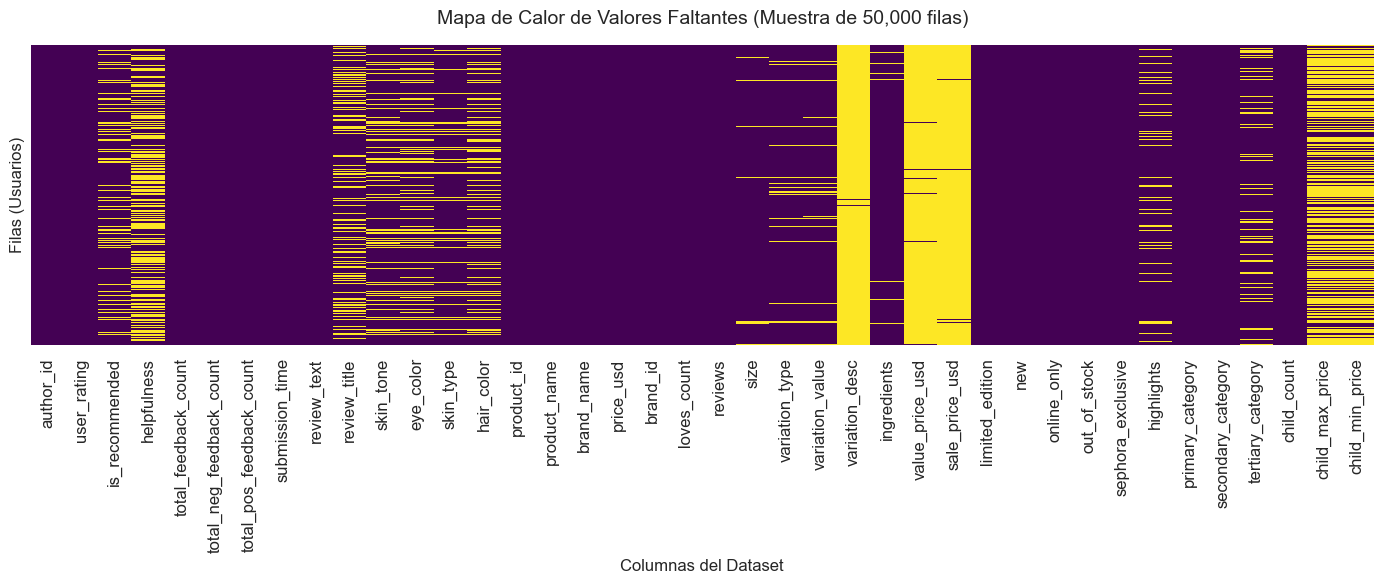

In [6]:
# Se genera un mapa de calor para visualizar la distribución de los valores faltantes en el dataset
print("Generando mapa de calor... (esto puede tomar unos segundos)")

# Se usa una muestra aleatoria de 50,000 filas para que el mapa de calor sea legible y no se sobrecargue visualmente
df_muestra = df_final.sample(n=50000, random_state=42)

plt.figure(figsize=(14, 6))
# Se visualizan los nulos
sns.heatmap(df_muestra.isna(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Mapa de Calor de Valores Faltantes (Muestra de 50,000 filas)', fontsize=14, pad=15)
plt.xlabel('Columnas del Dataset', fontsize=12)
plt.ylabel('Filas (Usuarios)', fontsize=12)
plt.tight_layout()
plt.show()

## Estadísticas descriptivas
Se muestran estadísticas:
- Numéricas y categóricas usando `.describe()`.
- Para categóricas se utiliza `include='object'`.

Esto da una vista general de rangos, frecuencias y posibles señales de limpieza requerida (por ejemplo, valores constantes, rangos extraños, etc.).

In [7]:
# Se muestra el número de columnas numéricas y categóricas (object) para entender la composición del dataset
num_cols = df_final.select_dtypes(include=["number"]).columns
cat_cols = df_final.select_dtypes(include=["object"]).columns

print("Número de columnas numéricas:", len(num_cols))
print("Número de columnas categóricas (object):", len(cat_cols))

print("\n--- describe() numéricas ---")
# Se muestra el resumen estadístico de las columnas numéricas para entender su distribución, media, mediana, etc.
display(df_final[num_cols].describe().T)

print("\n--- describe() categóricas (top/frecuencia) ---")
# Se muestra el resumen estadístico de las columnas categóricas para entender su distribución, valores más frecuentes, etc.
if len(cat_cols) > 0: # Si hay columnas categóricas, se muestra su descripción
    display(df_final[cat_cols].describe(include="object").T)
else: # Si no hay columnas categóricas, se muestra un mensaje indicando que no existen
    print("No hay columnas categóricas tipo 'object'.")


Número de columnas numéricas: 20
Número de columnas categóricas (object): 20

--- describe() numéricas ---


,count,mean,std,min,25%,50%,75%,max
user_rating,1094411.0,4.299158,1.149444,1.0,4.000000,5.000000,5.0,5.0
is_recommended,926423.0,0.839962,0.366642,0.0,1.000000,1.000000,1.0,1.0
helpfulness,532819.0,0.767782,0.317164,0.0,0.652174,0.928571,1.0,1.0
total_feedback_count,1094411.0,4.177126,22.715238,0.0,0.000000,0.000000,3.0,5464.0
total_neg_feedback_count,1094411.0,0.894869,5.288943,0.0,0.000000,0.000000,1.0,1159.0
total_pos_feedback_count,1094411.0,3.282257,19.674818,0.0,0.000000,0.000000,3.0,5050.0
price_usd,1094411.0,49.008382,40.043383,3.0,25.000000,39.000000,62.0,1900.0
brand_id,1094411.0,5548.417747,1492.131805,1063.0,5626.000000,6073.000000,6234.0,8017.0
loves_count,1094411.0,106861.518321,167710.158594,0.0,16656.000000,48739.000000,123439.0,1081315.0
reviews,1094411.0,2160.949483,2526.749510,1.0,552.000000,1350.000000,2911.0,16118.0



--- describe() categóricas (top/frecuencia) ---


,count,unique,top,freq
author_id,1094411,578653,1696370280,234
submission_time,1094411,5317,2020-06-11,2028
review_text,1092967,969419,I received this in a sample. I have alot of ac...,59
review_title,783757,364105,Love it!,6125
skin_tone,923872,14,light,266418
eye_color,884783,6,brown,471181
skin_type,982854,4,combination,544513
hair_color,867643,7,brown,403099
product_id,1094411,2351,P420652,16138
product_name,1094411,2334,Lip Sleeping Mask Intense Hydration with Vitam...,16138


### Conclusiones de las Estadísticas Descriptivas

El análisis descriptivo permitió comprender mejor la estructura y comportamiento general de las variables presentes en el dataset.

**Variables numéricas**
1. **Alta valoración de los productos:** La variable user_rating presenta una media de 4,30 sobre 5 y una mediana de 5, lo que indica que la mayoría de las reseñas son positivas.
2. **Desbalance en la variable objetivo:** La variable is_recommended muestra una proporción promedio de 0,84, lo que significa que aproximadamente el 84% de los usuarios recomienda el producto. Este comportamiento evidencia un desbalance de clases que deberá considerarse durante la fase de modelado.
3. **Distribuciones asimétricas y presencia de valores extremos:** Variables como total_feedback_count, total_pos_feedback_count, total_neg_feedback_count, loves_count y reviews presentan máximos muy superiores a sus cuartiles superiores, lo que sugiere distribuciones sesgadas y posibles valores atípicos.
4. **Amplio rango de precios:** La variable price_usd presenta valores entre USD 3 y USD 1.900, reflejando una alta diversidad de productos dentro del catálogo analizado.

**Variables categóricas**
1. **Gran cantidad de usuarios únicos:** La variable author_id registra más de 578 mil usuarios distintos, lo que evidencia una alta diversidad de clientes participando en la plataforma.
2. **Predominio de ciertas categorías de usuarios:** Entre las variables demográficas destacan:
- skin_tone: predominio de usuarios con tono de piel light.
- eye_color: predominio de color de ojos brown.
- hair_color: predominio de cabello brown.
- skin_type: predominio de piel tipo combination.
3. **Baja variabilidad en algunas variables:** La variable primary_category presenta una única categoría (Skincare), por lo que podría aportar poca capacidad discriminativa en modelos predictivos.
4. **Alta cardinalidad en algunas variables:** Variables como product_id, product_name, review_text y author_id contienen una gran cantidad de valores únicos, por lo que requerirán un tratamiento especial durante el preprocesamiento para evitar problemas de dimensionalidad.

## Análisis de la variable objetivo (is_recommended)
Se explora la variable `is_recommended` si existe en el dataset integrado.

Se reporta:
- Frecuencias absolutas.
- Frecuencias relativas.
- Gráfico de conteo con `sns.countplot()`.

,Frecuencia,Porcentaje (%)
is_recommended,,
1.0,778160,71.1031
NaN,167988,15.3496
0.0,148263,13.5473


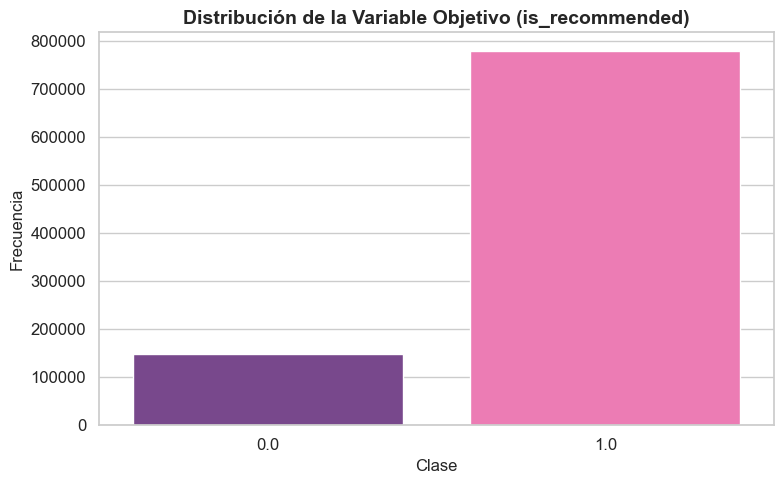

In [8]:
# Se define el nombre de la variable objetivo que será utilizada en los modelos supervisadOS
target_col = "is_recommended"

# Se verifica que la columna exista en el dataset antes de realizar el análisis
if target_col in df_final.columns:

    # Se calcula la frecuencia absoluta de cada categoría, incluyendo los valores nulos (NaN)
    vc = df_final[target_col].value_counts(dropna=False)

    # Se calcula el porcentaje que representa cada categoría
    rel = (vc / len(df_final)) * 100

    # Se construye una tabla resumen con frecuencias y porcentajes
    df_target = pd.DataFrame({
        "Frecuencia": vc,
        "Porcentaje (%)": rel.round(4),
    })

    # Se muestra la tabla
    display(df_target)

    # Se genera un gráfico de barras de la variable objetivo
    plt.figure(figsize=(8, 5))

    # Se define una paleta de colores personalizada para el gráfico de barras
    paleta_custom = ["#7D3C98", "#FF69B4"]

    ax = sns.countplot(
        data=df_final,
        x=target_col,
        palette=paleta_custom
    )
    ax.set_title(
        "Distribución de la Variable Objetivo (is_recommended)",
        fontsize=14,
        fontweight="bold"
    )
    ax.set_xlabel(
        "Clase",
        fontsize=12
    )
    ax.set_ylabel(
        "Frecuencia",
        fontsize=12
    )
    plt.tight_layout()
    plt.show()

# Si la variable objetivo no existe, se informa al usuario
else:
    print("La columna 'is_recommended' no existe en el dataset integrado.")

### Conclusiones del Análisis de la Variable Objetivo

El análisis de la variable objetivo (`is_recommended`) permitió identificar aspectos relevantes para las etapas posteriores de modelado.

1. **Presencia de valores faltantes:** Se observó que el 15,35% de los registros no poseen información sobre si el usuario recomienda o no el producto. Debido a que esta variable corresponde a la etiqueta utilizada en el aprendizaje supervisado, estos registros deberán ser excluidos antes del entrenamiento de los modelos.

2. **Desbalance de clases:** Entre los registros válidos, aproximadamente el 84% corresponde a usuarios que recomiendan el producto, mientras que solo el 16% no lo recomienda. Esto indica la existencia de un desbalance de clases que deberá considerarse al seleccionar métricas de evaluación y durante el proceso de validación.

3. **Predominio de opiniones positivas:** La alta proporción de recomendaciones sugiere que la mayoría de las experiencias registradas en el dataset son favorables, lo que coincide con los altos valores observados previamente en la variable `user_rating`.

4. **Implicancias para el modelado:** Debido al desbalance observado, métricas como Accuracy podrían resultar insuficientes para evaluar el desempeño de los modelos. Por ello será recomendable utilizar métricas adicionales como Precision, Recall y F1-Score durante la fase de evaluación.

## Análisis de variables categóricas principales

### Análisis de Variables Categóricas

Al analizar la frecuencia de las categorías y las marcas en nuestro dataset, nuestro enfoque cambia: ya no medimos el tamaño del catálogo, sino **el volumen de participación de los clientes (engagement)**. 

De los gráficos generados se pudo extraer:

1. **Dominio de categorías:** Queda clarísimo que **Skincare** y **Makeup** son los que lideran en la plataforma, acaparando la inmensa mayoría de las reseñas.
2. **Liderazgo de marcas:** **CLINIQUE** domina por completo el análisis, seguida por **Tatcha**. Estas marcas han logrado que sus usuarios dejen comentarios masivamente.
3. **Limpieza de datos:** A diferencia de nuestro diagnóstico inicial en el catálogo, la variable `primary_category` presenta un formato limpio sin saltos de línea ocultos, lo que facilitará el trabajo en el Pipeline.

Top 10 Marcas con más reseñas:
brand_name
CLINIQUE               49029
Tatcha                 46770
Drunk Elephant         42395
fresh                  40886
The Ordinary           35934
Glow Recipe            31490
Youth To The People    29154
Origins                29063
Peter Thomas Roth      28846
LANEIGE                27519
Name: count, dtype: int64


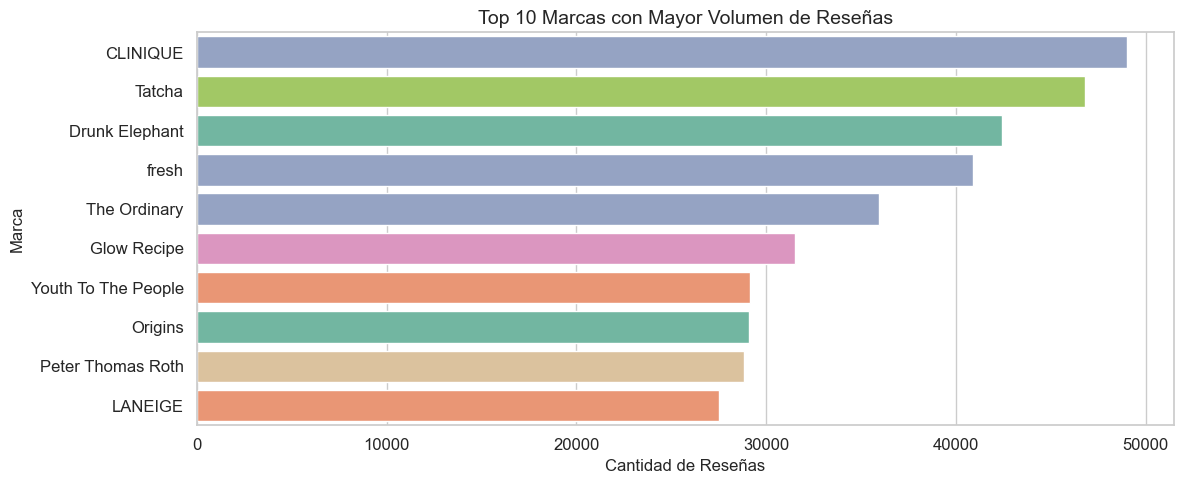

In [9]:
# Se exploran las marcas más populares que generan más conversación entre los usuarios
print('Top 10 Marcas con más reseñas:')
print(df_final['brand_name'].value_counts().head(10))

plt.figure(figsize=(12, 5))
ax = sns.countplot(data=df_final, y='brand_name', 
                   order=df_final['brand_name'].value_counts().head(10).index, 
                   palette='Set2', hue='brand_name', legend=False)
ax.set_title('Top 10 Marcas con Mayor Volumen de Reseñas', fontsize=14)
ax.set_xlabel('Cantidad de Reseñas', fontsize=12)
ax.set_ylabel('Marca', fontsize=12)
plt.tight_layout()
plt.show()

## Análisis de distribución

### Análisis de Distribuciones Numéricas
Tras corregir los formatos de texto (como los precios) y eliminar las variables sin datos, los histogramas nos revelan el comportamiento real de nuestras variables:

1. **Tendencia Positiva en las Calificaciones (`user_rating`):** La distribución está fuertemente hacia la izquierda, con un pico en la calificación de 5 estrellas. Esto indica que los usuarios de Sephora tienden a dejar reseñas principalmente cuando están muy satisfechos con el producto.
2. **Distribución de Precios (`price_usd`, `value_price_usd`):** Los precios presentan una linea positiva (hacia la derecha). La gran concentración de productos se encuentra en un rango de precios bajos a medios, con una cola larga, que representa un grupo selecto de artículos de lujo de alto valor.
3. **Interacción y Viralidad (`helpfulness`, `loves_count`, `total_feedback_count`):** Estas variables de "engagement" muestran una caída extrema. La inmensa mayoría de las reseñas y productos reciben poca interacción o votos de utilidad, pero unos pocos logran volverse "virales", acumulando cientos o miles de interacciones.
4. **Filtro de Variables:** Cabe destacar que para este análisis de distribución continua se excluyeron las variables de identificación (IDs) y las variables binarias (ej. `is_recommended` o `online_only`), ya que al ser categoricas, deforma este tipo de visualización.

Además se calcula la media y mediana para cada variable mostrada.

Variables numéricas continuas detectadas para graficar:
['user_rating', 'helpfulness', 'total_feedback_count', 'total_neg_feedback_count', 'total_pos_feedback_count', 'price_usd', 'loves_count', 'reviews', 'value_price_usd', 'sale_price_usd', 'child_count', 'child_max_price', 'child_min_price']


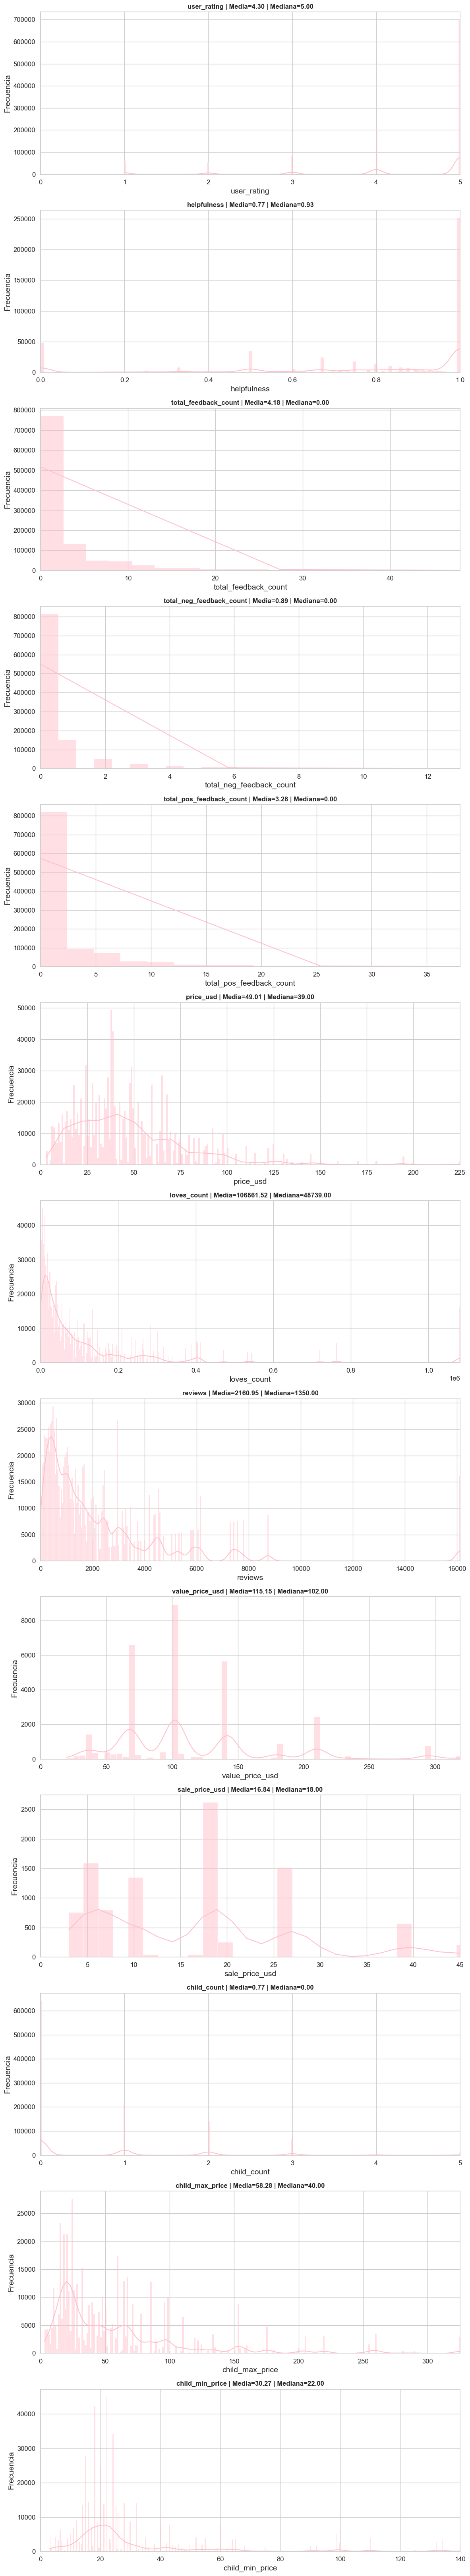

In [10]:
# Se seleccionan únicamente las variables numéricas
numeric_cols = df_final.select_dtypes(include=['number']).columns.tolist()

# Excluimos los IDs y las variables que son binarias (0 y 1) para no deformar los histogramas
columnas_a_excluir = [
    'brand_id',
    'is_recommended',
    'limited_edition',
    'new',
    'online_only',
    'out_of_stock',
    'sephora_exclusive'
]

numeric_cols = [col for col in numeric_cols if col not in columnas_a_excluir]

print("Variables numéricas continuas detectadas para graficar:")
print(numeric_cols)

# Si hay variables numéricas, se gráfica
if numeric_cols:

    n_numeric = len(numeric_cols)

    fig, axs = plt.subplots(
        n_numeric,
        1,
        figsize=(12, 5 * n_numeric),
        squeeze=False
    )

    axs = axs.flatten()

    for ax, col in zip(axs, numeric_cols):

        series = df_final[col].dropna()

        mean_val = series.mean()
        median_val = series.median()

        # Para evitar que los histogramas se deformen por valores
        upper_limit = series.quantile(0.99)

        sns.histplot(
            data=df_final,
            x=col,
            kde=True,
            ax=ax,
            color="pink"
        )

        # Limitar el eje x para evitar que los outliers deformen la visualización
        ax.set_xlim(0, upper_limit)
        
        ax.set_title(
            f"{col} | Media={mean_val:.2f} | Mediana={median_val:.2f}",
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel(col)
        ax.set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

else:
    print("No se encontraron variables numéricas válidas.")

## Detección de Outliers


### Detección de Valores Atípicos (Outliers)
Durante el análisis de distribución, identificamos que varias de nuestras variables continuas (como los precios y las métricas de interacción) presentaban colas muy largas hacia la derecha, indicando la presencia de valores atípicos extremos.

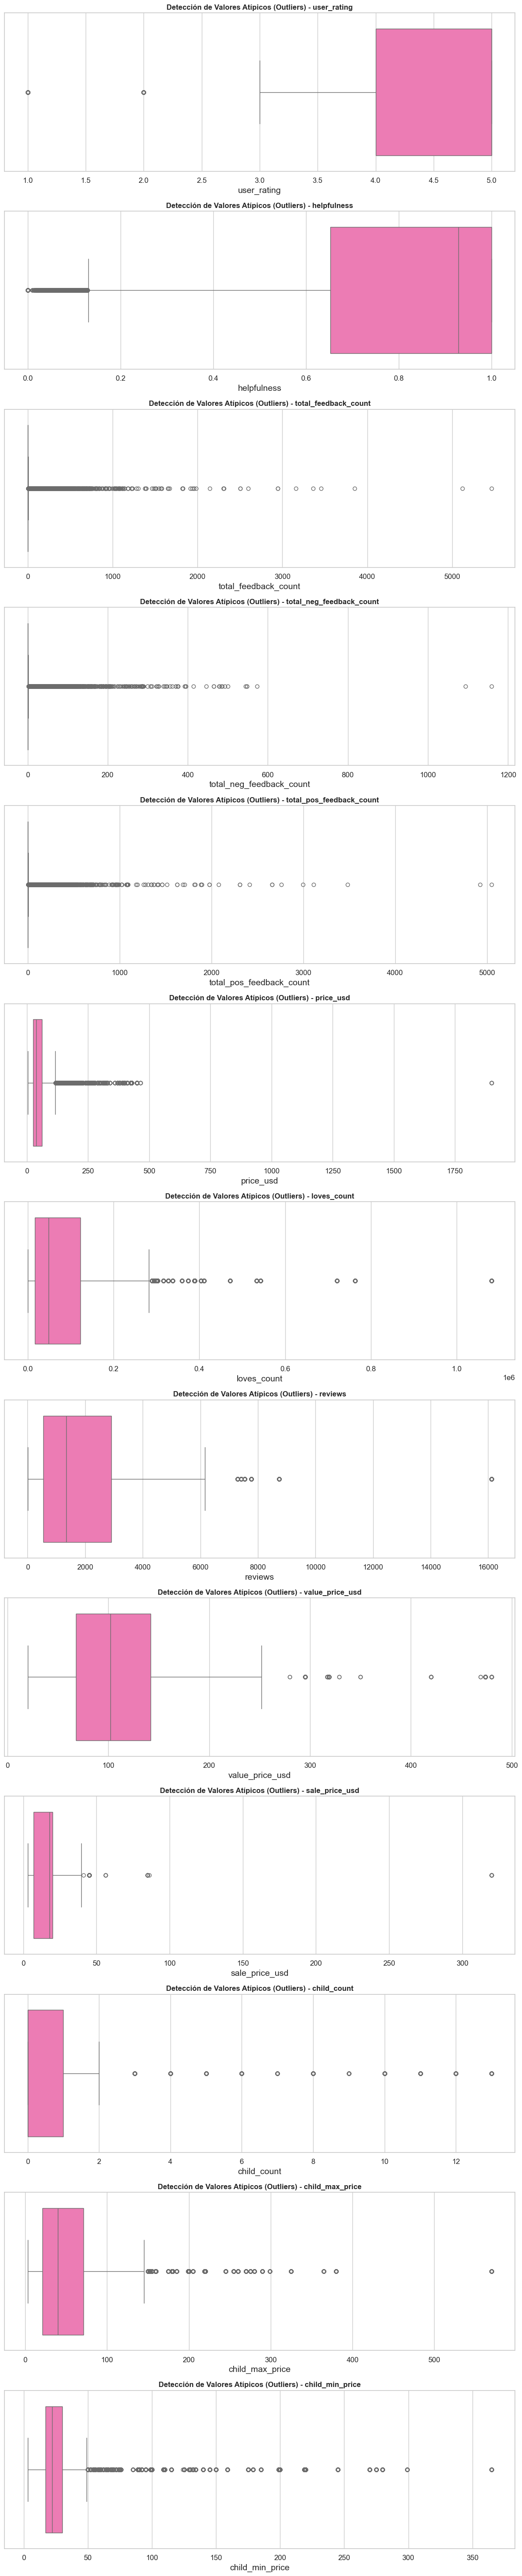

In [11]:
# Se utilizan las variables numéricas continuas identificadas previamente
cols_outliers = numeric_cols

# Se verifica que existan columnas numéricas para analizar
if not cols_outliers:

    print("No hay columnas numéricas candidatas para analizar outliers.")

else:

    # Se calcula la cantidad de variables a graficar
    n_outliers = len(cols_outliers)

    # Se crea una figura con un boxplot por variable
    fig, axs = plt.subplots(
        n_outliers,
        1,
        figsize=(12, 4.5 * n_outliers),
        squeeze=False
    )

    # Se convierte la matriz de ejes en un arreglo unidimensional
    axs = axs.flatten()

    # Se genera un boxplot para cada variable numérica
    for ax, col in zip(axs, cols_outliers):

        sns.boxplot(
            data=df_final,
            x=col,
            ax=ax,
            color="hotpink"
        )

        ax.set_title(
            f"Detección de Valores Atípicos (Outliers) - {col}",
            fontsize=12,
            fontweight="bold"
        )

        ax.set_xlabel(col)

    # Ajusta automáticamente los espacios entre gráficos
    plt.tight_layout()

    # Muestra todos los boxplots
    plt.show()

## Análisis de Correlación

### Análisis de Correlación
Se calcula la matriz de correlación de Pearson para variables numéricas

Interpretación EDA:
- Valores cercanos a 1: correlación positiva fuerte.
- Valores cercanos a -1: correlación negativa fuerte.
- Valores cercanos a 0: relación lineal débil.

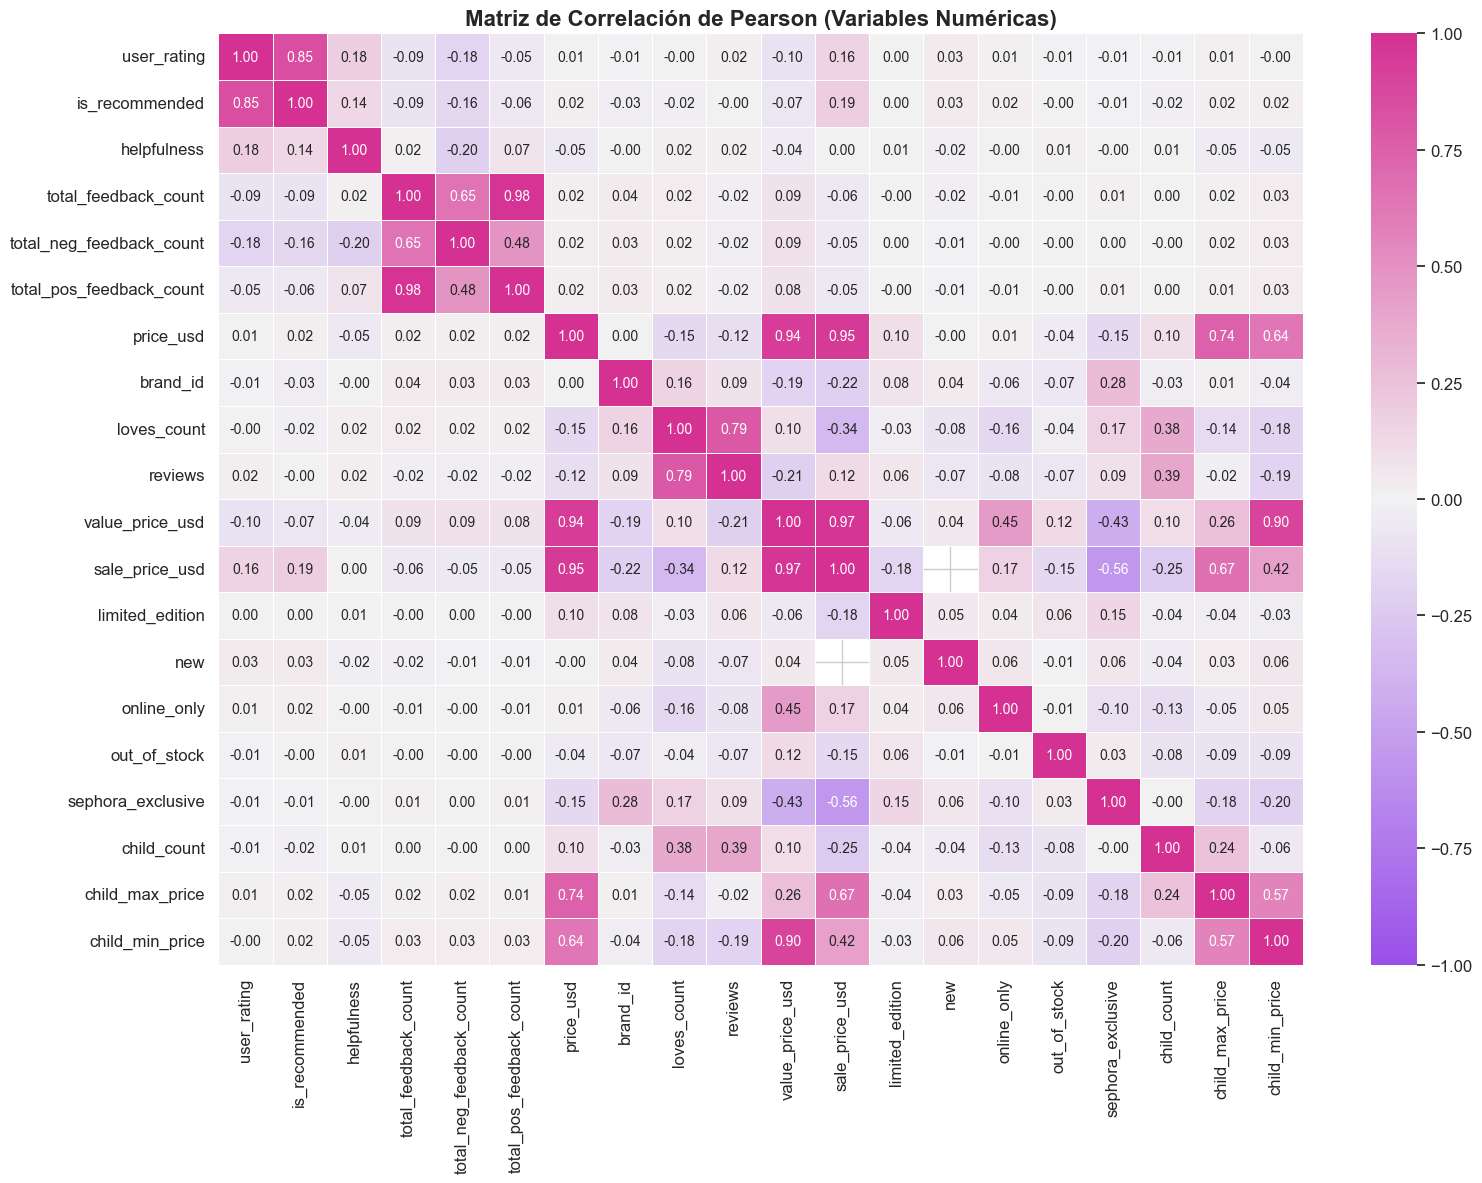


=== Top 10 correlaciones positivas con price_usd ===


price_usd                   1.000000
sale_price_usd              0.952221
value_price_usd             0.938209
child_max_price             0.744217
child_min_price             0.636879
child_count                 0.101256
limited_edition             0.096923
total_feedback_count        0.021480
total_neg_feedback_count    0.021083
is_recommended              0.019731
Name: price_usd, dtype: float64


=== Top 10 correlaciones negativas con price_usd ===


total_pos_feedback_count    0.019132
online_only                 0.007983
user_rating                 0.007105
brand_id                    0.002416
new                        -0.000376
out_of_stock               -0.039494
helpfulness                -0.052726
reviews                    -0.118684
loves_count                -0.149454
sephora_exclusive          -0.149799
Name: price_usd, dtype: float64

In [12]:
# Se calcula la matriz de correlación utilizando únicamente variables numéricas
corr_matrix = df_final.corr(numeric_only=True)

# Se verifica que existan suficientes variables numéricas para calcular correlaciones
if corr_matrix.empty:
    print("No hay variables numéricas suficientes para calcular correlaciones.")

else:
    plt.figure(figsize=(16, 12))

    # Se crea una paleta de colores en tonos rosa y morado
    paleta_rosa_morado = sns.diverging_palette(
        280,
        340,
        s=85,
        l=50,
        as_cmap=True
    )

    sns.heatmap(
        corr_matrix,
        cmap=paleta_rosa_morado,
        center=0,
        annot=True,        
        fmt=".2f",           # Redondea a 2 decimales para que se vea limpio
        annot_kws={"size": 10}, 
        linewidths=0.5,
        vmin=-1,
        vmax=1
    )

    plt.title(
        "Matriz de Correlación de Pearson (Variables Numéricas)",
        fontsize=16,   
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # Se analiza específicamente la variable precio si existe
    ref_col = "price_usd"

    if ref_col in corr_matrix.columns:
        # Correlaciones ordenadas de mayor a menor
        correlaciones_precio = (
            corr_matrix[ref_col]
            .dropna()
            .sort_values(ascending=False)
        )

        print("\n=== Top 10 correlaciones positivas con price_usd ===")
        display(correlaciones_precio.head(10))

        print("\n=== Top 10 correlaciones negativas con price_usd ===")
        display(correlaciones_precio.tail(10))

### Interpretación de la Matriz de Correlación

El análisis de correlación de Pearson permite identificar cómo se relacionan linealmente las variables del catálogo de Sephora. A partir del mapa de calor y los listados obtenidos, se extraen las siguientes conclusiones fundamentales:

1. Colinealidad Crítica en Variables de Precios
Existe una correlación positiva extremadamente fuerte (cercana a 1.0) entre las variables financieras:
- **`price_usd` con `sale_price_usd` (0.95)** y **`value_price_usd` (0.94)**.
- **`price_usd` con las variantes de producto `child_max_price` (0.74)** y **`child_min_price` (0.64)**.

**Implicancia para el modelo:** Este fenómeno se conoce como *Multicolinealidad*. Si decidimos usar el precio en un modelo predictivo, mantener todas estas variables juntas aportaría información redundante y podría distorsionar la estabilidad de algoritmos lineales. Se recomienda seleccionar únicamente `price_usd` como representante del costo del producto.

2. Interacción del Usuario (Engagement)
Se observa una relación casi perfecta dentro de las métricas de feedback y popularidad:
- **`total_feedback_count` con `total_pos_feedback_count` (0.98):** Indica que ambas variables contienen información muy similar y evolucionan conjuntamente. Esto sugiere que una gran parte de la interacción total está asociada a retroalimentación positiva.
- **`reviews` con `loves_count` (0.79):** Existe una fuerte relación que indica que los productos que acumulan más reseñas escritas son de igual manera los que los usuarios guardan con más frecuencia en sus listas de favoritos ("loves").

3. El Vínculo Estrecho de la Satisfacción
- **`user_rating` con `is_recommended` (0.85):** Como era de esperarse, existe una correlación positiva muy alta entre la puntuación por estrellas dada por el cliente y su decisión explícita de recomendar el producto. Un puntaje alto es un predictor directo de una recomendación positiva.

4. Variables Completamente Independientes del Precio (`price_usd`)
Al analizar el comportamiento del precio respecto a las demás características del negocio, destacan dos puntos muy interesantes:
- **Precio vs Calidad percibida (Cercana a 0):** La correlación entre `price_usd` y `user_rating` (0.01) o `is_recommended` (0.02) es prácticamente nula. Esto demuestra matemáticamente que **el precio de un producto en Sephora no influye en si al cliente le gusta o si lo recomienda**. Los productos costosos no reciben mejores notas que los económicos.
- **Precio vs Exclusividad (`sephora_exclusive` = -0.15):** Existe una correlación negativa leve que sugiere que los productos etiquetados como exclusivos de la cadena Sephora tienden a ubicarse en rangos de precio ligeramente más moderados o competitivos en comparación con marcas externas de lujo distribuidas en la tienda.

## Conclusiones del Análisis Exploratorio

Tras realizar el Análisis Exploratorio de Datos (EDA) sobre el dataset de Sephora, utilizamos este entorno para diagnosticar y validar las transformaciones que nuestros datos necesitan. Los hallazgos críticos son:

1. **Gestión de Nulos, Redundancias y Variables Inutilizables:**
   Al revisar la estructura del dataset, se identificaron varios problemas de integridad que deben ser tratados:
   * **Columnas con basura:** La variable `Unnamed: 0` es un índice arrastrado del archivo original y no aporta valor predictivo.
   * **Extrema falta de datos:** Variables como `variation_desc`, `sale_price_usd` y `value_price_usd` presentan más del 97% de valores nulos, estas deben ser descartadas.
   * **Redundancia por cruce de tablas:** Se detectaron variables duplicadas con sufijos `_x` e `_y` (ej. `price_usd_x` y `price_usd_y`, `brand_name_x` y `brand_name_y`). Se deberá seleccionar una única versión para evitar redundancia.

2. **Desafíos de Formato y Tipado (Dirty Data):**
   Descubrimos que la variable `price_usd` venía clasificada como texto debido al símbolo `$`. Al limpiarla manualmente durante el EDA, logramos desbloquear todo el análisis estadístico.